In [150]:
import os
import glob
import gc
from pathlib import Path

import numpy as np
from sklearn import linear_model
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import anndata as ad
import scanpy as sc
import pegasus as pg
from pegasusio import UnimodalData

import celltypist
from celltypist import models
from celltypist.classifier import AnnotationResult

%matplotlib inline

In [2]:
adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata_annotated_w_celltypist_scanvi.h5ad')

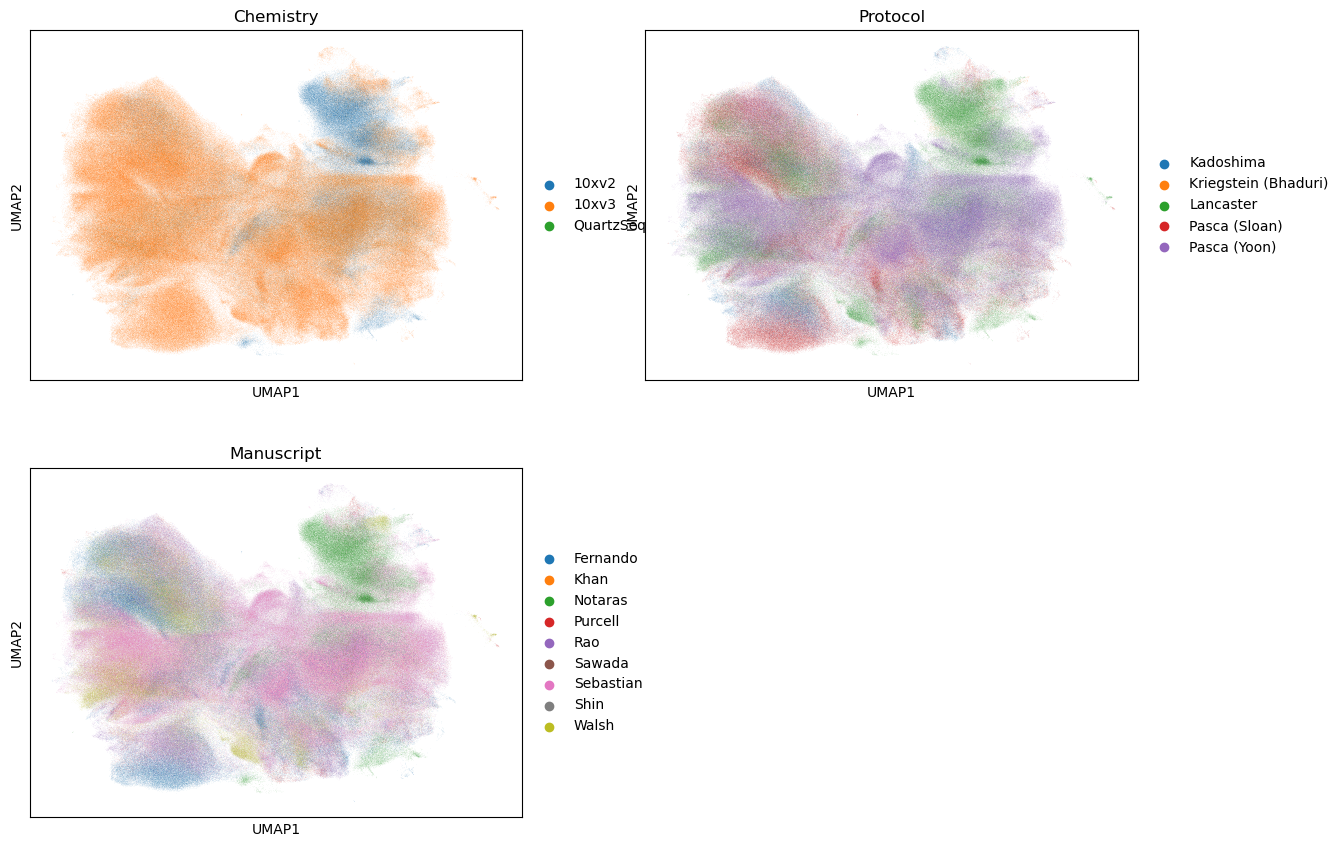

In [393]:
sc.pl.umap(adata, color=['Chemistry', 'Protocol', 'Manuscript'], ncols=2)

In [52]:
adata.obs['Broad_Genotype'].unique()

['NRXN1del', 'Control', '22q11.2del', 'Idiopathic_Schizophrenia', '3q29del', '15q13.3del']
Categories (6, object): ['3q29del', '15q13.3del', '22q11.2del', 'Control', 'Idiopathic_Schizophrenia', 'NRXN1del']

In [378]:
manuscript_dx_dict = {'Fernando':'NRXN1del', 'Shin':'22q11.2del', 'Khan':'22q11.2del', 
                      'Sawada':'Idiopathic_Schizophrenia', 'Purcell':'3q29del', 'Walsh_15q13.3del':'15q13.3del', 
                      'Walsh_22q11.2del':'22q11.2del', 'Rao':'22q11.2del', 'Notaras':'Idiopathic_Schizophrenia', 
                      'Sebastian':'NRXN1del'}

In [373]:
manuscript_markers_dict = {}

for manuscript in adata.obs['Manuscript'].unique():
    adata_sub = adata[adata.obs['Manuscript'] == manuscript].copy()
    adata_sub.X = adata_sub.X.astype('float32')
    pg.de_analysis(adata_sub, cluster='subclass_annotations', condition='Broad_Genotype', de_key=f'{manuscript}_DE')
    manuscript_markers_dict[manuscript] = pg.markers(adata_sub, de_key=f'{manuscript}_DE')
    del adata_sub
    gc.collect()

2026-04-10 13:25:15,203 - pegasus.tools.diff_expr - INFO - CSR matrix is converted to CSC matrix. Time spent = 5.92s.
2026-04-10 13:25:50,609 - pegasus.tools.diff_expr - INFO - Differential expression analysis is finished.
2026-04-10 13:25:50,611 - pegasus.tools.diff_expr - INFO - Function 'de_analysis' finished in 41.33s.
2026-04-10 13:25:57,302 - pegasus.tools.diff_expr - INFO - CSR matrix is converted to CSC matrix. Time spent = 0.55s.
2026-04-10 13:26:03,534 - pegasus.tools.diff_expr - INFO - Differential expression analysis is finished.
2026-04-10 13:26:03,536 - pegasus.tools.diff_expr - INFO - Function 'de_analysis' finished in 6.79s.
2026-04-10 13:26:07,022 - pegasus.tools.diff_expr - INFO - CSR matrix is converted to CSC matrix. Time spent = 0.31s.
_perform_de_cond finished for clusters Dorsal Forebrain EN.
_perform_de_cond finished for clusters GABAergic.
2026-04-10 13:26:10,569 - pegasus.tools.diff_expr - INFO - Differential expression analysis is finished.
2026-04-10 13:26:1

In [374]:
## Fix Walsh ##

walsh = manuscript_markers_dict["Walsh"]

diseases = ["15q13.3del", "22q11.2del"]

new_entries = {}

for disease in diseases:
    
    new_key = f"Walsh_{disease}"
    new_entries[new_key] = {}

    for celltype, d in walsh.items():
        
        # skip control-only entries
        if disease not in d:
            continue
        
        # IMPORTANT: disease becomes the direct key (no 'up')
        new_entries[new_key][celltype] = {disease: d[disease]}

# replace original Walsh entry
manuscript_markers_dict.update(new_entries)
del manuscript_markers_dict["Walsh"]

In [379]:
manuscript_rows = []

manuscript_marker_dict_keys = list(manuscript_markers_dict.keys())

for manuscript in manuscript_marker_dict_keys:
    manuscript_dict = {}
    for cell_type in adata.obs['subclass_annotations'].unique():
        if cell_type in manuscript_markers_dict[manuscript].keys() and 'up' in manuscript_markers_dict[manuscript][cell_type][manuscript_dx_dict[manuscript]].keys():
            temp_df = manuscript_markers_dict[manuscript][cell_type][manuscript_dx_dict[manuscript]]['up']
            manuscript_dict[cell_type] = temp_df.shape[0]
        else:
            print(manuscript)
            manuscript_dict[cell_type] = 0
    manuscript_rows.append(manuscript_dict)

Fernando
Khan
Sawada


In [380]:
scDGE_df = pd.DataFrame(data=manuscript_rows, index=manuscript_marker_dict_keys)

In [381]:
scDGE_df[['Dorsal Forebrain EN', 'GABAergic', 'Hindbrain Neurons', 'Mesenchymal-like cells', 'Mixed Neurons', 'Proliferative Radial Glia', 'Radial Glia', 'Stressed Glia']]

,Dorsal Forebrain EN,GABAergic,Hindbrain Neurons,Mesenchymal-like cells,Mixed Neurons,Proliferative Radial Glia,Radial Glia,Stressed Glia
Fernando,6730,8688,1572,9980,3192,7608,13239,0
Shin,2072,0,2089,2535,359,2301,2203,0
Khan,168,21,122,2,12,419,848,0
Sawada,0,0,89,0,0,1479,4248,0
Purcell,6545,846,2205,1139,666,2611,7159,0
Rao,931,955,426,1875,4320,8679,1786,0
Notaras,405,32,265,2509,37,2955,4101,0
Sebastian,3063,3989,2221,8134,2952,821,3799,0
Walsh_15q13.3del,383,32,284,973,141,29,175,0
Walsh_22q11.2del,14503,13634,15280,2308,14528,13973,14893,0


_perform_de_cond finished for clusters Stressed Glia.
_perform_de_cond finished for clusters Mesenchymal-like cells.
_perform_de_cond finished for clusters Radial Glia.
_perform_de_cond finished for clusters Mixed Neurons.
_perform_de_cond finished for clusters Dorsal Forebrain EN.
_perform_de_cond finished for clusters Stressed Glia.
_perform_de_cond finished for clusters Mesenchymal-like cells.
_perform_de_cond finished for clusters Stressed Glia.
_perform_de_cond finished for clusters Hindbrain Neurons.
_perform_de_cond finished for clusters Dorsal Forebrain EN.
_perform_de_cond finished for clusters Proliferative Radial Glia.
_perform_de_cond finished for clusters Dorsal Forebrain EN.
_perform_de_cond finished for clusters GABAergic.
_perform_de_cond finished for clusters Radial Glia.
_perform_de_cond finished for clusters Mixed Neurons.
_perform_de_cond finished for clusters Proliferative Radial Glia.
_perform_de_cond finished for clusters GABAergic.
_perform_de_cond finished for 

In [234]:
## Shin..Nowakowski 22q11 Dataset ##

# objective is to take one dataset, annotate it quickly outside of my scVI engineered space, and see if that restores DGEs #

shin = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/studies/fernando_brennand/anndata_objs/fernando_qc.h5ad')

In [329]:
shin.obs['Broad_Genotype'] = shin.obs['Genotype'].apply(lambda x: 'NRXN1del' if 'NRXN1' in x else x)

In [235]:
# Load your model (or pretrained model)

# hnoca annotations #
hnoca_tissue_model = models.Model.load('/home/deepak/datasets/reference_atlas_models/hnoca_tissue_model.pkl')
hnoca_cell_type_model = models.Model.load('/home/deepak/datasets/reference_atlas_models/hnoca_cell_type_model.pkl')
hnoca_annot_level_2 = models.Model.load('/home/deepak/datasets/reference_atlas_models/hnoca_annot_level_2_model.pkl')

# braun annotations #
braun_model = models.Model.load('/home/deepak/datasets/reference_atlas_models/Braun_Linarsson_Developing_Human_Brain.pkl')
braun_subregion_model = models.Model.load('/home/deepak/datasets/reference_atlas_models/braun_subregion_model.pkl')
braun_tissue_model = models.Model.load('/home/deepak/datasets/reference_atlas_models/braun_tissue_model.pkl')
braun_cellclass_model = models.Model.load('/home/deepak/datasets/reference_atlas_models/braun_cellclass_model.pkl')
braun_subregion_cellclass_model = models.Model.load('/home/deepak/datasets/reference_atlas_models/braun_subregion_cellclass_model.pkl')

In [236]:
## Annotate w/ Braun ##

org_braun_predictions = celltypist.annotate(shin, model = braun_model, majority_voting = False)

org_braun_subregion_model_predictions = celltypist.annotate(shin, model = braun_subregion_model, majority_voting = False)

org_braun_tissue_model_predictions = celltypist.annotate(shin, model = braun_tissue_model, majority_voting = False)

org_braun_cellclass_model_predictions = celltypist.annotate(shin, model = braun_cellclass_model, majority_voting = False)

org_braun_subregion_cellclass_model_predictions = celltypist.annotate(shin, model = braun_subregion_cellclass_model, 
                                                                      majority_voting = False)

## Annotate w/ HNOCA Atlas ##

org_hnoca_tissue_predictions = celltypist.annotate(shin, model = hnoca_tissue_model, majority_voting = False)

org_hnoca_cell_type_predictions = celltypist.annotate(shin, model = hnoca_cell_type_model, majority_voting = False)

org_hnoca_annot_level_2_predictions = celltypist.annotate(shin, model = hnoca_annot_level_2, majority_voting = False)

⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 342481 cells and 18828 genes
🔗 Matching reference genes in the model
🧬 773 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 342481 cells and 18828 genes
🔗 Matching reference genes in the model
🧬 1574 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 342481 cells and 18828 genes
🔗 Matching reference genes in the model
🧬 1574 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels


In [237]:
## Apply Annotations ##

shin.obs['braun_overall_ct'] = org_braun_predictions.predicted_labels
shin.obs['braun_subregion_ct'] = org_braun_subregion_model_predictions.predicted_labels
shin.obs['braun_tissue_ct'] = org_braun_tissue_model_predictions.predicted_labels
shin.obs['braun_cellclass_ct'] = org_braun_cellclass_model_predictions.predicted_labels
shin.obs['braun_subregion_cellclass_ct'] = org_braun_subregion_cellclass_model_predictions.predicted_labels

shin.obs['hnoca_tissue_ct'] = org_hnoca_tissue_predictions.predicted_labels
shin.obs['hnoca_celltype_ct'] = org_hnoca_cell_type_predictions.predicted_labels
shin.obs['hnoca_annot_level_2_ct'] = org_hnoca_annot_level_2_predictions.predicted_labels

In [263]:
shin.obsm['X_umap_harmonized'] = shin.obsm['X_umap']

In [275]:
if isinstance(shin, ad.AnnData):
    shin = UnimodalData(shin)

pg.neighbors(shin, rep='pca_regressed', use_cache=False, dist='l2', K=100, n_comps=30)
pg.leiden(shin, rep='pca_regressed', resolution=0.5, class_label='leiden')
pg.umap(shin, rep='pca_regressed', n_neighbors=15, rep_ncomps=30)
shin = shin.to_anndata()

2026-04-10 12:24:16,966 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 39.34s.
2026-04-10 12:24:22,561 - pegasus.tools.nearest_neighbors - INFO - Function 'calculate_affinity_matrix' finished in 5.59s.
2026-04-10 12:24:29,570 - pegasus.tools.graph_operations - INFO - Function 'construct_graph' finished in 7.01s.
2026-04-10 12:25:47,009 - pegasus.tools.clustering - INFO - Leiden clustering is done. Get 13 clusters.
2026-04-10 12:25:47,207 - pegasus.tools.clustering - INFO - Function 'leiden' finished in 84.64s.
2026-04-10 12:25:47,208 - pegasus.tools.nearest_neighbors - INFO - Found cached kNN results, no calculation is required.
2026-04-10 12:25:47,209 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 0.00s.
UMAP(min_dist=0.5, n_jobs=1, precomputed_knn=(array([[     0, 170792, 301460, ..., 75899, 107409, 41],
       [     1, 107407, 81, ..., 170832, 318528, 107531],
       [     2, 324696, 324702, ..., 301440, 18, 39859],
 

Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Fri Apr 10 12:27:57 2026 Finished embedding
2026-04-10 12:27:57,487 - pegasus.tools.visualization - INFO - Function 'umap' finished in 130.28s.


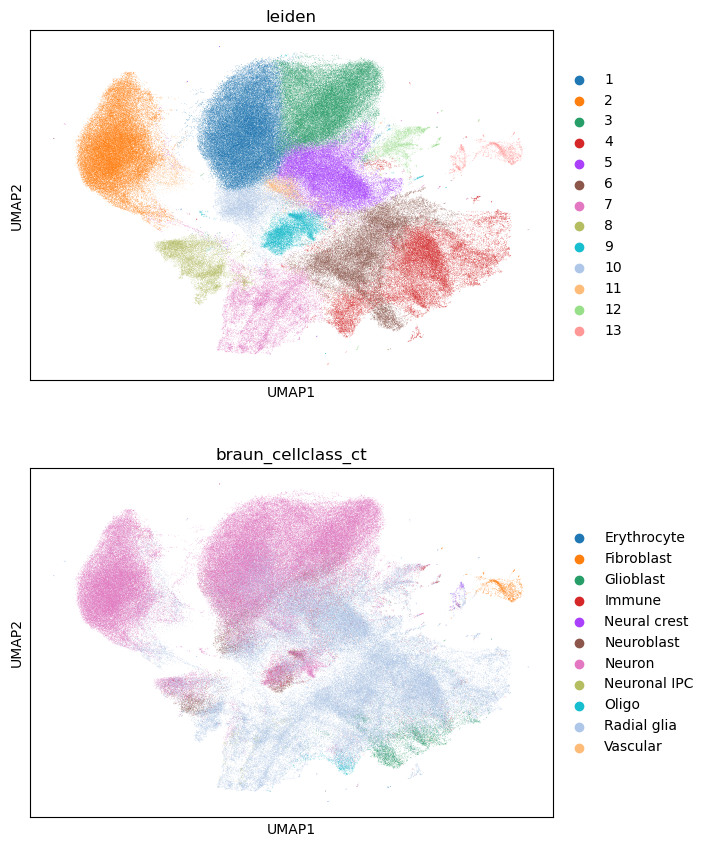

In [277]:
sc.pl.umap(shin, color=['leiden', 'braun_cellclass_ct'], ncols=1)

In [278]:
# contingency table: Leiden clusters vs Braun cell classes
ct = pd.crosstab(shin.obs['leiden'], shin.obs['braun_cellclass_ct'])

# majority vote mapping (leiden -> dominant cell class)
majority_map = ct.idxmax(axis=1)

# add to AnnData
shin.obs['leiden_majority_cellclass'] = shin.obs['leiden'].map(majority_map)

# optional: confidence of assignment (purity of cluster)
shin.obs['leiden_majority_conf'] = shin.obs['leiden'].map(ct.max(axis=1) / ct.sum(axis=1))

shin.obs['leiden_majority_cellclass'] = shin.obs['leiden_majority_cellclass'].astype('str')

... storing 'leiden_majority_cellclass' as categorical


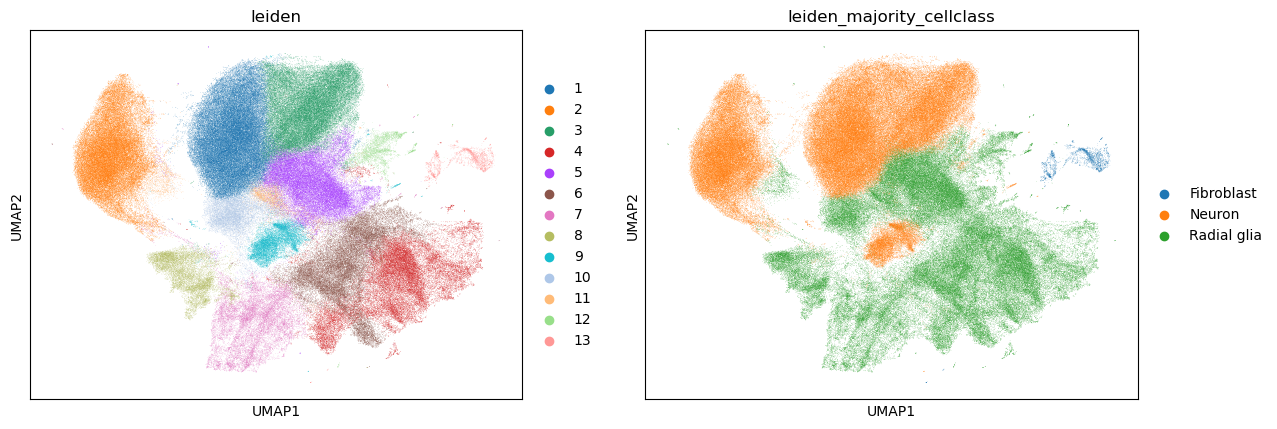

In [279]:
sc.pl.umap(shin, color=['leiden', 'leiden_majority_cellclass'], ncols=2)

In [331]:
pg.de_analysis(shin, cluster='leiden', condition='Broad_Genotype')

2026-04-10 13:04:49,661 - pegasus.tools.diff_expr - INFO - CSR matrix is converted to CSC matrix. Time spent = 4.00s.
2026-04-10 13:05:13,989 - pegasus.tools.diff_expr - INFO - Differential expression analysis is finished.
2026-04-10 13:05:13,990 - pegasus.tools.diff_expr - INFO - Function 'de_analysis' finished in 28.46s.


In [332]:
dge_shin = pg.markers(shin)

In [333]:
rows = []

dge = dge_shin   # your object

for celltype, geno_dict in dge.items():
    for genotype, de_dict in geno_dict.items():
        for direction in ['up', 'down']:
            
            if direction not in de_dict:
                continue
            
            df = de_dict[direction].copy()
            df = df.reset_index()  # brings featurekey into column
            
            df['celltype'] = celltype
            df['genotype'] = genotype
            df['direction'] = direction
            
            rows.append(df)

df_flat = pd.concat(rows, ignore_index=True)

In [334]:
df_flat[(df_flat['direction'] == 'up') & (df_flat['log2FC'] > 1) & (df_flat['mwu_qval'] < 0.05)]

,featurekey,log2Mean,log2Mean_other,log2FC,percentage,percentage_other,percentage_fold_change,auroc,mwu_U,mwu_pval,mwu_qval,celltype,genotype,direction
34264,RPS10,2.237291,0.947602,1.289688,92.392509,54.785938,1.686427,0.838382,325705519.5,0.000000e+00,0.000000e+00,2,NRXN1del,up
84665,RPS26,2.401323,1.242078,1.159245,96.672043,75.114182,1.287001,0.833759,194094396.5,0.000000e+00,0.000000e+00,4,NRXN1del,up
84666,FTH1,4.583247,3.564539,1.018708,99.499657,98.016441,1.015132,0.713668,166137736.0,0.000000e+00,0.000000e+00,4,NRXN1del,up
106586,RPS26,2.280848,1.180627,1.100221,92.522110,70.086266,1.320118,0.792871,111506425.5,0.000000e+00,0.000000e+00,5,NRXN1del,up
114250,NPY,1.330060,0.074691,1.255369,56.338688,5.743083,9.809833,0.763424,144750385.5,0.000000e+00,0.000000e+00,6,Control,up
127125,RPS26,2.328116,1.197333,1.130783,93.675171,70.481834,1.329068,0.774632,146875408.5,0.000000e+00,0.000000e+00,6,NRXN1del,up
140000,PTPRZ1,2.060998,0.990498,1.070500,87.085388,67.083168,1.298170,0.759958,32060270.5,0.000000e+00,0.000000e+00,7,Control,up
160051,RPS26,2.545255,1.094643,1.450612,91.310677,61.363636,1.488026,0.865412,444790.5,5.149336e-17,4.406895e-14,8,NRXN1del,up
160059,MT-ND4,3.662549,2.636279,1.026271,95.676743,79.545456,1.202793,0.707998,363885.5,1.838331e-06,2.933229e-04,8,NRXN1del,up
160070,RPS4X,3.193148,2.089658,1.103489,93.194077,72.727272,1.281419,0.689582,354420.5,1.370153e-05,1.554051e-03,8,NRXN1del,up


In [335]:
# filter to UP significant DEGs
#df_sig = df_flat[(df_flat['direction'] == 'up') & (df_flat['log2FC'] > 1) & (df_flat['mwu_qval'] < 0.05)]
df_sig = df_flat[(df_flat['direction'] == 'up') & (df_flat['mwu_qval'] < 0.05)]
# count genes per celltype × genotype
summary = (df_sig.groupby(['genotype', 'celltype']).size().unstack(fill_value=0))

# optional: reorder columns if you want a fixed atlas order
# summary = summary.reindex(columns=[...your preferred cell types...])

summary

celltype,1,10,11,12,13,2,3,4,5,6,7,8,9
genotype,,,,,,,,,,,,,
Control,8441,930,1079,4011,763,2176,2755,962,3393,1289,1721,296,4957
NRXN1del,3002,5754,513,1626,9022,9202,9628,13295,4271,11586,8114,85,1383


In [288]:
shin_1_2 = shin[shin.obs['leiden'].isin(['1','2'])]

In [296]:
pg.de_analysis(shin_1_2, cluster='Genotype')

2026-04-10 12:33:30,178 - pegasus.tools.diff_expr - INFO - CSR matrix is converted to CSC matrix. Time spent = 1.2716s.
2026-04-10 12:33:32,815 - pegasus.tools.diff_expr - INFO - MWU test and AUROC calculation are finished. Time spent = 2.6367s.
2026-04-10 12:33:33,008 - pegasus.tools.diff_expr - INFO - Sufficient statistics are collected. Time spent = 0.1928s.
2026-04-10 12:33:33,021 - pegasus.tools.diff_expr - INFO - Differential expression analysis is finished.
2026-04-10 12:33:33,022 - pegasus.tools.diff_expr - INFO - Function 'de_analysis' finished in 4.12s.


In [297]:
shin_1_2_dge = pg.markers(shin_1_2)

In [306]:
(shin_1_2_dge["3'-NRXN1-Deletion"]['up'])

,log2Mean,log2Mean_other,log2FC,percentage,percentage_other,percentage_fold_change,auroc,mwu_U,mwu_pval,mwu_qval
featurekey,,,,,,,,,,
RPS26,2.349879,1.125139,1.224739,95.780800,74.845596,1.279712e+00,0.871969,3.149585e+09,0.000000,0.000000
RPL10,3.885908,3.331001,0.554907,99.674164,99.195465,1.004826e+00,0.715495,2.584394e+09,0.000000,0.000000
RPS4Y1,1.290020,0.869417,0.420602,76.600945,55.654919,1.376355e+00,0.630295,2.276650e+09,0.000000,0.000000
RPL34,3.234489,2.947082,0.287407,98.941032,98.707962,1.002361e+00,0.610891,2.206562e+09,0.000000,0.000000
LDHA,0.684704,0.286816,0.397887,38.931778,19.314800,2.015645e+00,0.606198,2.189610e+09,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
ATOH1,0.000106,0.000000,0.000106,0.009257,0.000000,1.000000e+30,0.500046,1.806186e+09,0.012846,0.021317
BTC,0.000053,0.000000,0.000053,0.009257,0.000000,1.000000e+30,0.500046,1.806186e+09,0.012846,0.021317
ALPK2,0.000051,0.000000,0.000051,0.007405,0.000000,1.000000e+30,0.500037,1.806152e+09,0.026059,0.040975


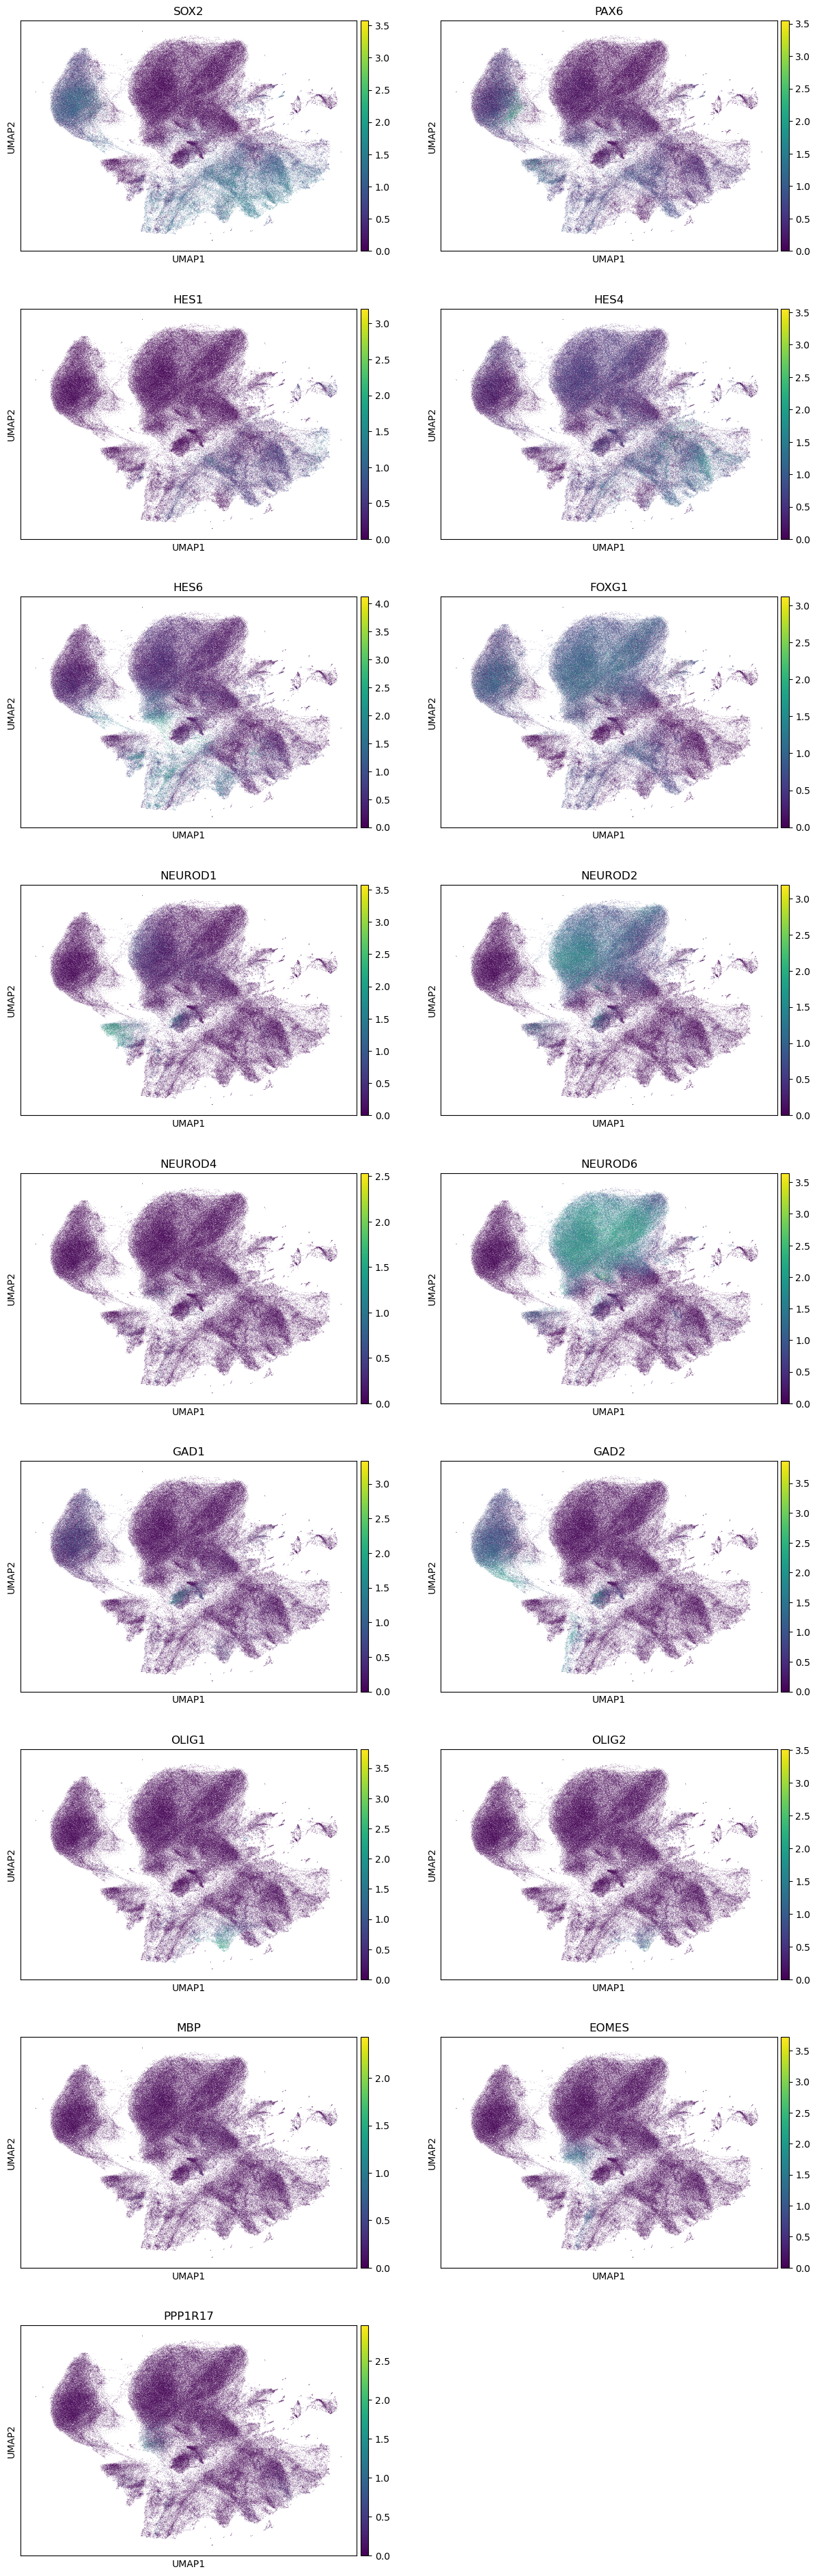

_perform_de_cond finished for clusters 12.
_perform_de_cond finished for clusters 15.
_perform_de_cond finished for clusters 14.
_perform_de_cond finished for clusters 9.
_perform_de_cond finished for clusters 13.
_perform_de_cond finished for clusters 11.
_perform_de_cond finished for clusters 10.
_perform_de_cond finished for clusters 16,17.
_perform_de_cond finished for clusters 8.
_perform_de_cond finished for clusters 2.
_perform_de_cond finished for clusters 5.
_perform_de_cond finished for clusters 4.
_perform_de_cond finished for clusters 7.
_perform_de_cond finished for clusters 6.
_perform_de_cond finished for clusters 3.
_perform_de_cond finished for clusters 1.


In [274]:
sc.pl.umap(shin, color=['SOX2', 'PAX6', 'HES1', 'HES4', 'HES6', 
                        'FOXG1', 'NEUROD1', 'NEUROD2', 'NEUROD4',
                        'NEUROD6', 'GAD1', 'GAD2', 'OLIG1', 'OLIG2', 
                        'MBP', 'EOMES', 'PPP1R17'], ncols=2)